# 06 - Rule Extraction: Multi-Method Knowledge Distillation

Estrazione di regole interpretabili dal modello EfficientNet-B5 (04b best) tramite 3 metodi complementari.

**Metodi:**
1. **Decision Tree Distillation** — Regole globali via albero decisionale su feature CNN
2. **RIPPER Rule Learning** — Regole if-then ottimizzate (Repeated Incremental Pruning)
3. **LIME Explanations** — Spiegazioni locali per immagine, confronto con Grad-CAM++

**Approccio:** Knowledge distillation — i rule extractors apprendono a imitare le predizioni della CNN (non le label ground truth). La metrica chiave e la **fidelity** (agreement con CNN).

**Ref:**
- Craven & Shavlik (1996) — Extracting Tree-Structured Representations of Trained Networks
- Cohen (1995) — RIPPER: Fast Effective Rule Induction
- Ribeiro et al. (2016) — LIME: Local Interpretable Model-agnostic Explanations

## 1. Setup e Caricamento Modello

In [26]:
import os
import sys
import time
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
import json

import numpy as np
import pandas as pd
import yaml

import torch
import torch.nn.functional as F
import timm
from torch.utils.data import Dataset, DataLoader

import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

import wittgenstein as lw
import lime
import lime.lime_image
from skimage.segmentation import mark_boundaries

from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm.auto import tqdm

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")

PyTorch: 2.9.1+cu130
CUDA: True


In [27]:
def get_project_root():
    notebook_dir = Path.cwd()
    if notebook_dir.name == 'notebooks':
        return notebook_dir.parent
    current = notebook_dir
    for _ in range(5):
        if (current / 'Data').exists():
            return current
        current = current.parent
    if sys.platform == 'linux' and Path('/mnt/c').exists():
        return Path('/mnt/c/Repository/multi-method-xai-diabetic-retinopathy')
    return Path('C:/Repository/multi-method-xai-diabetic-retinopathy')


PROJECT_ROOT = get_project_root()
with open(PROJECT_ROOT / 'config.yaml', 'r') as f:
    config = yaml.safe_load(f)

PROCESSED_DIR = PROJECT_ROOT / config['paths']['processed_dir']
RESULTS_DIR = PROJECT_ROOT / config['paths']['results_dir']
CHECKPOINTS_DIR = PROJECT_ROOT / config['paths']['checkpoints_dir']
RULE_DIR = RESULTS_DIR / 'rule_extraction'
RULE_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_CLASSES = config['model']['num_classes']

# Normalizza CLASS_NAMES a lista di stringhe (config.yaml usa dict {0: 'No DR', ...})
_cn = config['model']['class_names']
CLASS_NAMES = list(_cn.values()) if isinstance(_cn, dict) else list(_cn)

MEAN = np.array([0.485, 0.456, 0.406])
STD = np.array([0.229, 0.224, 0.225])

val_transforms = A.Compose([
    A.Normalize(mean=MEAN.tolist(), std=STD.tolist()),
    ToTensorV2()
])

print(f"Project root: {PROJECT_ROOT}")
print(f"Device: {DEVICE}")
print(f"Output: {RULE_DIR}")
print(f"Classi: {CLASS_NAMES}")

Project root: /mnt/c/Repository/multi-method-xai-diabetic-retinopathy
Device: cuda
Output: /mnt/c/Repository/multi-method-xai-diabetic-retinopathy/results/rule_extraction
Classi: ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative']


In [28]:
# Carica modello 04b
CHECKPOINT_PATH = CHECKPOINTS_DIR / 'best_model_20260118_224715.pt'

model = timm.create_model(
    config['model']['architecture'],
    pretrained=False,
    num_classes=NUM_CLASSES,
    drop_rate=config['model']['dropout_rate']
)

checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(DEVICE)
model.eval()

print(f"Modello: {CHECKPOINT_PATH.name}")
print(f"Epoch: {checkpoint['epoch']}, Best Kappa: {checkpoint['best_score']:.4f}")

# Carica dataset
aptos_df = pd.read_csv(PROCESSED_DIR / 'aptos_preprocessed.csv')
eyepacs_df = pd.read_csv(PROCESSED_DIR / 'eyepacs_preprocessed.csv')
messidor_df = pd.read_csv(PROCESSED_DIR / 'messidor2_preprocessed.csv')

merged_df = pd.concat([aptos_df, eyepacs_df], ignore_index=True)
train_df, val_df = train_test_split(
    merged_df, test_size=0.15, stratify=merged_df['diagnosis'], random_state=42
)
test_df = messidor_df.copy()

print(f"\nTrain: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")

Modello: best_model_20260118_224715.pt
Epoch: 17, Best Kappa: 0.9088

Train: 32,243 | Val: 5,690 | Test: 1,744


## 2. Feature Extraction

Estraiamo il vettore di feature 2048-dimensionale dal penultimate layer (Global Average Pooling) per ogni immagine. Queste feature catturano la rappresentazione semantica appresa dalla CNN.

In [29]:
class DRDataset(Dataset):
    """Dataset per immagini DR preprocessate."""
    def __init__(self, dataframe, transform=None, project_root=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.project_root = project_root
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row['preprocessed_path']
        if self.project_root and not Path(img_path).is_absolute():
            img_path = self.project_root / img_path
        
        image = cv2.imread(str(img_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']
        
        label = torch.tensor(row['diagnosis'], dtype=torch.long)
        return image, label


@torch.no_grad()
def extract_features(model, dataloader, device):
    """Estrae feature 2048-dim e predizioni CNN per tutto il dataset."""
    all_features = []
    all_cnn_preds = []
    all_labels = []
    
    model.eval()
    for images, labels in tqdm(dataloader, desc='Feature extraction'):
        images = images.to(device)
        
        # Feature extraction via timm API
        feats = model.forward_features(images)
        features = model.forward_head(feats, pre_logits=True)  # (B, 2048)
        
        # CNN predictions
        logits = model.forward_head(feats)  # (B, 5)
        preds = logits.argmax(dim=1)
        
        all_features.append(features.cpu().numpy())
        all_cnn_preds.append(preds.cpu().numpy())
        all_labels.append(labels.numpy())
    
    return (
        np.concatenate(all_features),
        np.concatenate(all_cnn_preds),
        np.concatenate(all_labels)
    )

print("Dataset e funzione di feature extraction definiti.")

Dataset e funzione di feature extraction definiti.


In [30]:
# Estrai feature per train, val e test
BATCH_SIZE = 64

splits = {
    'train': train_df,
    'val': val_df,
    'test': test_df
}

features = {}
cnn_preds = {}
true_labels = {}

for split_name, df in splits.items():
    print(f"\n--- {split_name.upper()} ({len(df):,} immagini) ---")
    
    dataset = DRDataset(df, transform=val_transforms, project_root=PROJECT_ROOT)
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    
    feats, preds, labels = extract_features(model, loader, DEVICE)
    features[split_name] = feats
    cnn_preds[split_name] = preds
    true_labels[split_name] = labels
    
    print(f"  Features shape: {feats.shape}")
    print(f"  CNN accuracy vs GT: {accuracy_score(labels, preds)*100:.1f}%")

# Salva features raw
for split_name in splits:
    np.savez_compressed(
        RULE_DIR / f'features_{split_name}.npz',
        features=features[split_name],
        cnn_preds=cnn_preds[split_name],
        true_labels=true_labels[split_name]
    )

print(f"\nFeature salvate in {RULE_DIR}")


--- TRAIN (32,243 immagini) ---


Feature extraction:   0%|          | 0/504 [00:00<?, ?it/s]

  Features shape: (32243, 2048)
  CNN accuracy vs GT: 84.8%

--- VAL (5,690 immagini) ---


Feature extraction:   0%|          | 0/89 [00:00<?, ?it/s]

  Features shape: (5690, 2048)
  CNN accuracy vs GT: 84.9%

--- TEST (1,744 immagini) ---


Feature extraction:   0%|          | 0/28 [00:00<?, ?it/s]

  Features shape: (1744, 2048)
  CNN accuracy vs GT: 67.2%

Feature salvate in /mnt/c/Repository/multi-method-xai-diabetic-retinopathy/results/rule_extraction


PCA: 2048 -> 12 componenti (95.2% varianza)
  train: (32243, 12)
  val: (5690, 12)
  test: (1744, 12)


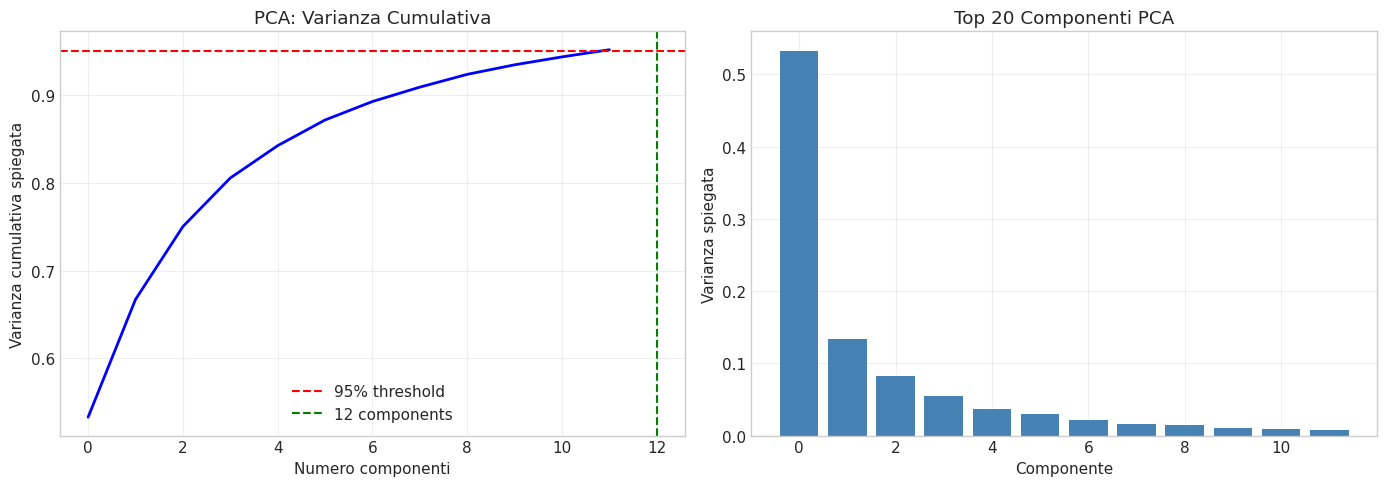

In [31]:
# PCA: riduzione dimensionalita (2048 -> N componenti, 95% varianza)
pca = PCA(n_components=0.95, random_state=42)
pca.fit(features['train'])

n_components = pca.n_components_
explained_var = pca.explained_variance_ratio_.sum()

print(f"PCA: 2048 -> {n_components} componenti ({explained_var*100:.1f}% varianza)")

# Trasforma tutti gli split
features_pca = {}
for split_name in splits:
    features_pca[split_name] = pca.transform(features[split_name])
    print(f"  {split_name}: {features_pca[split_name].shape}")

# Feature names per interpretabilita
FEATURE_NAMES = [f'PC{i+1}' for i in range(n_components)]

# Plot varianza cumulativa
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(np.cumsum(pca.explained_variance_ratio_), 'b-', linewidth=2)
axes[0].axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
axes[0].axvline(x=n_components, color='g', linestyle='--', label=f'{n_components} components')
axes[0].set_xlabel('Numero componenti')
axes[0].set_ylabel('Varianza cumulativa spiegata')
axes[0].set_title('PCA: Varianza Cumulativa')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].bar(range(min(20, n_components)), pca.explained_variance_ratio_[:20], color='steelblue')
axes[1].set_xlabel('Componente')
axes[1].set_ylabel('Varianza spiegata')
axes[1].set_title('Top 20 Componenti PCA')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RULE_DIR / 'pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Method 1: Decision Tree Distillation

Knowledge distillation: il Decision Tree apprende a replicare le predizioni della CNN, non le label originali. La **fidelity** misura quanto bene il DT imita la CNN.

In [32]:
def evaluate_rule_extractor(name, y_pred, cnn_pred, y_true, class_names):
    """Calcola metriche per un rule extractor."""
    fidelity = accuracy_score(cnn_pred, y_pred)
    accuracy = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    f1_per_class = f1_score(y_true, y_pred, average=None, zero_division=0)
    
    # Fidelity per classe
    fidelity_per_class = []
    for cls in range(len(class_names)):
        mask = cnn_pred == cls
        if mask.sum() > 0:
            fidelity_per_class.append((y_pred[mask] == cnn_pred[mask]).mean())
        else:
            fidelity_per_class.append(0.0)
    
    results = {
        'method': name,
        'fidelity': fidelity,
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'f1_per_class': {class_names[i]: float(f1_per_class[i]) for i in range(len(class_names))},
        'fidelity_per_class': {class_names[i]: float(fidelity_per_class[i]) for i in range(len(class_names))}
    }
    
    print(f"\n{'=' * 60}")
    print(f"{name}")
    print(f"{'=' * 60}")
    print(f"  Fidelity (vs CNN):  {fidelity*100:.1f}%")
    print(f"  Accuracy (vs GT):   {accuracy*100:.1f}%")
    print(f"  F1 Macro:           {f1_macro:.4f}")
    print(f"\n  {'Classe':<20} {'Fidelity':>10} {'F1':>10}")
    print(f"  {'-'*42}")
    for i, name_cls in enumerate(class_names):
        print(f"  {name_cls:<20} {fidelity_per_class[i]*100:>9.1f}% {f1_per_class[i]:>10.4f}")
    
    return results

print("Funzione di valutazione definita.")

Funzione di valutazione definita.


Ablation Study: Decision Tree max_depth
 depth    nodes   leaves   fidelity_val    acc_val  fidelity_test   acc_test
--------------------------------------------------------------------------------
     4       31       16          87.6%      85.5%          76.3%      70.5%
     6      127       64          90.9%      85.7%          82.7%      68.2%
     8      433      217          92.0%      84.4%          85.8%      67.7%
    10     1091      546          92.7%      84.6%          87.7%      66.2%
    12     1909      955          92.6%      84.3%          88.2%      65.8%
    16     2763     1382          92.2%      83.7%          88.3%      65.5%


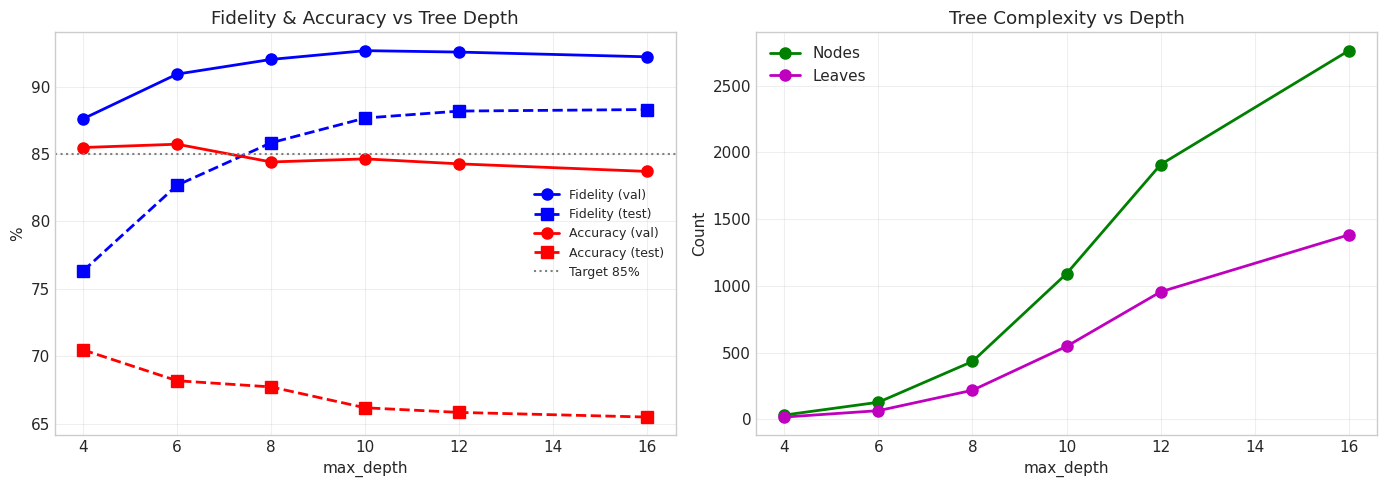

In [33]:
# Ablation study: max_depth
DEPTHS = [4, 6, 8, 10, 12, 16]
ablation_results = []

print("Ablation Study: Decision Tree max_depth")
print(f"{'depth':>6} {'nodes':>8} {'leaves':>8} {'fidelity_val':>14} {'acc_val':>10} {'fidelity_test':>14} {'acc_test':>10}")
print("-" * 80)

for depth in DEPTHS:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(features_pca['train'], cnn_preds['train'])
    
    # Metriche validation
    pred_val = dt.predict(features_pca['val'])
    fid_val = accuracy_score(cnn_preds['val'], pred_val)
    acc_val = accuracy_score(true_labels['val'], pred_val)
    
    # Metriche test
    pred_test = dt.predict(features_pca['test'])
    fid_test = accuracy_score(cnn_preds['test'], pred_test)
    acc_test = accuracy_score(true_labels['test'], pred_test)
    
    n_nodes = dt.tree_.node_count
    n_leaves = dt.tree_.n_leaves
    
    ablation_results.append({
        'depth': depth, 'nodes': n_nodes, 'leaves': n_leaves,
        'fidelity_val': fid_val, 'accuracy_val': acc_val,
        'fidelity_test': fid_test, 'accuracy_test': acc_test
    })
    
    print(f"{depth:>6} {n_nodes:>8} {n_leaves:>8} {fid_val*100:>13.1f}% {acc_val*100:>9.1f}% {fid_test*100:>13.1f}% {acc_test*100:>9.1f}%")

# Plot ablation
abl_df = pd.DataFrame(ablation_results)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(abl_df['depth'], abl_df['fidelity_val']*100, 'bo-', label='Fidelity (val)', linewidth=2, markersize=8)
axes[0].plot(abl_df['depth'], abl_df['fidelity_test']*100, 'bs--', label='Fidelity (test)', linewidth=2, markersize=8)
axes[0].plot(abl_df['depth'], abl_df['accuracy_val']*100, 'ro-', label='Accuracy (val)', linewidth=2, markersize=8)
axes[0].plot(abl_df['depth'], abl_df['accuracy_test']*100, 'rs--', label='Accuracy (test)', linewidth=2, markersize=8)
axes[0].axhline(y=85, color='gray', linestyle=':', label='Target 85%')
axes[0].set_xlabel('max_depth')
axes[0].set_ylabel('%')
axes[0].set_title('Fidelity & Accuracy vs Tree Depth')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].plot(abl_df['depth'], abl_df['nodes'], 'go-', label='Nodes', linewidth=2, markersize=8)
axes[1].plot(abl_df['depth'], abl_df['leaves'], 'mo-', label='Leaves', linewidth=2, markersize=8)
axes[1].set_xlabel('max_depth')
axes[1].set_ylabel('Count')
axes[1].set_title('Tree Complexity vs Depth')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RULE_DIR / 'dt_ablation_depth.png', dpi=150, bbox_inches='tight')
plt.show()

In [34]:
# Decision Tree finale con max_depth=12
dt_final = DecisionTreeClassifier(max_depth=12, random_state=42)
dt_final.fit(features_pca['train'], cnn_preds['train'])

dt_pred_val = dt_final.predict(features_pca['val'])
dt_pred_test = dt_final.predict(features_pca['test'])

print("=" * 60)
print("DECISION TREE (max_depth=12) - VALIDATION")
dt_val_results = evaluate_rule_extractor(
    'Decision Tree (d=12)', dt_pred_val, cnn_preds['val'], true_labels['val'], CLASS_NAMES
)

print("\n" + "=" * 60)
print("DECISION TREE (max_depth=12) - TEST")
dt_test_results = evaluate_rule_extractor(
    'Decision Tree (d=12)', dt_pred_test, cnn_preds['test'], true_labels['test'], CLASS_NAMES
)

# Statistiche albero
print(f"\nComplessita albero:")
print(f"  Nodi totali:    {dt_final.tree_.node_count}")
print(f"  Foglie:         {dt_final.tree_.n_leaves}")
print(f"  Profondita max: {dt_final.tree_.max_depth}")

DECISION TREE (max_depth=12) - VALIDATION

Decision Tree (d=12)
  Fidelity (vs CNN):  92.6%
  Accuracy (vs GT):   84.3%
  F1 Macro:           0.7181

  Classe                 Fidelity         F1
  ------------------------------------------
  No DR                     97.0%     0.9207
  Mild                      77.5%     0.4835
  Moderate                  88.6%     0.7528
  Severe                    75.0%     0.5776
  Proliferative             91.5%     0.8561

DECISION TREE (max_depth=12) - TEST

Decision Tree (d=12)
  Fidelity (vs CNN):  88.2%
  Accuracy (vs GT):   65.8%
  F1 Macro:           0.6218

  Classe                 Fidelity         F1
  ------------------------------------------
  No DR                     93.9%     0.7741
  Mild                      83.3%     0.3789
  Moderate                  83.7%     0.6364
  Severe                    87.7%     0.5735
  Proliferative             84.8%     0.7463

Complessita albero:
  Nodi totali:    1909
  Foglie:         955
  Profond

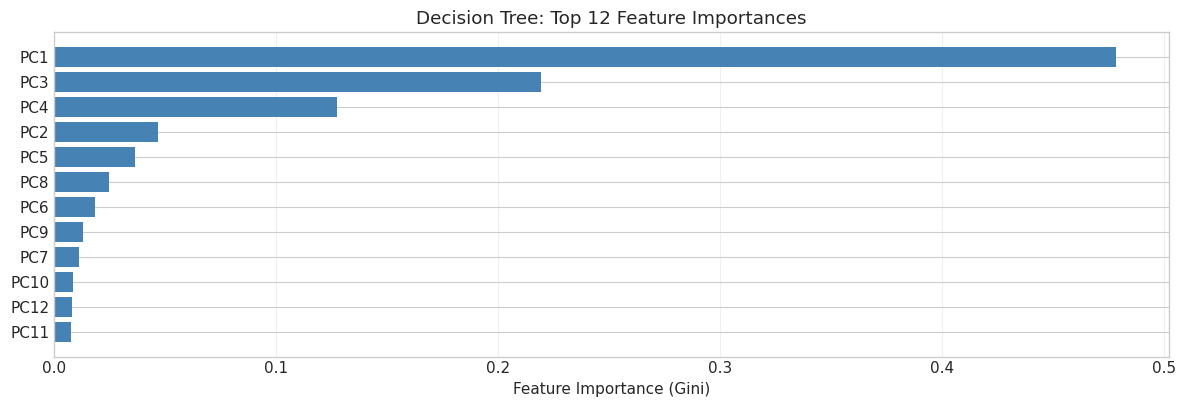

Regole Decision Tree (primi 4 livelli):
|--- PC1 <= -0.54
|   |--- PC1 <= -1.95
|   |   |--- PC2 <= -0.13
|   |   |   |--- PC12 <= -0.03
|   |   |   |   |--- PC3 <= -0.11
|   |   |   |   |   |--- truncated branch of depth 4
|   |   |   |   |--- PC3 >  -0.11
|   |   |   |   |   |--- truncated branch of depth 4
|   |   |   |--- PC12 >  -0.03
|   |   |   |   |--- PC1 <= -2.21
|   |   |   |   |   |--- truncated branch of depth 3
|   |   |   |   |--- PC1 >  -2.21
|   |   |   |   |   |--- truncated branch of depth 6
|   |   |--- PC2 >  -0.13
|   |   |   |--- PC5 <= 0.09
|   |   |   |   |--- PC3 <= 0.25
|   |   |   |   |   |--- truncated branch of depth 8
|   |   |   |   |--- PC3 >  0.25
|   |   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- PC5 >  0.09
|   |   |   |   |--- PC11 <= -0.13
|   |   |   |   |   |--- truncated branch of depth 3
|   |   |   |   |--- PC11 >  -0.13
|   |   |   |   |   |--- truncated branch of depth 6
|   |--- PC1 >  -1.95
|   |   |--- PC3 <= 0.23
|   |

In [35]:
# Visualizzazione: feature importance e regole
importances = dt_final.feature_importances_
n_feats = len(importances)
top_k = min(20, n_feats)
top_idx = np.argsort(importances)[-top_k:][::-1]
top_importances = importances[top_idx]
top_names = [FEATURE_NAMES[i] for i in top_idx]

fig, ax = plt.subplots(figsize=(12, max(4, top_k * 0.35)))
y_pos = np.arange(top_k)
ax.barh(y_pos, top_importances[::-1], color='steelblue')
ax.set_yticks(y_pos)
ax.set_yticklabels(top_names[::-1])
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title(f'Decision Tree: Top {top_k} Feature Importances')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(RULE_DIR / 'dt_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Mostra regole top (rami piu frequenti)
rules_text = export_text(dt_final, feature_names=FEATURE_NAMES, max_depth=4)
print("Regole Decision Tree (primi 4 livelli):")
print(rules_text[:3000])

## 4. Method 2: RIPPER Rule Learning

RIPPER (Cohen, 1995) genera regole if-then ottimizzate tramite pruning iterativo. A differenza del DT, produce un insieme ordinato di regole indipendenti.

In [36]:
# Prepara dati per RIPPER (One-vs-Rest: un modello per classe)
# wittgenstein.RIPPER supporta solo binary classification,
# quindi trainiamo 5 modelli binari e combiniamo le predizioni

def prepare_binary_df(features_pca, cnn_preds, feature_names, pos_class):
    """Crea DataFrame binario per RIPPER: pos_class vs rest."""
    df = pd.DataFrame(features_pca, columns=feature_names)
    df['target'] = (cnn_preds == pos_class).astype(int)
    return df

print(f"RIPPER One-vs-Rest: {NUM_CLASSES} modelli binari")
print(f"Features: {len(FEATURE_NAMES)} componenti PCA")
print(f"Training set: {len(features_pca['train'])} campioni")
print(f"\nDistribuzione CNN preds (train):")
for cls in range(NUM_CLASSES):
    n = (cnn_preds['train'] == cls).sum()
    print(f"  {CLASS_NAMES[cls]}: {n} ({n/len(cnn_preds['train'])*100:.1f}%)")

RIPPER One-vs-Rest: 5 modelli binari
Features: 12 componenti PCA
Training set: 32243 campioni

Distribuzione CNN preds (train):
  No DR: 21347 (66.2%)
  Mild: 4165 (12.9%)
  Moderate: 5231 (16.2%)
  Severe: 744 (2.3%)
  Proliferative: 756 (2.3%)


In [37]:
# Train RIPPER One-vs-Rest
print("Training RIPPER One-vs-Rest...")
t0 = time.time()

ripper_models = {}
ripper_rulesets = {}

for cls in range(NUM_CLASSES):
    print(f"\n  Training {CLASS_NAMES[cls]} vs Rest...", end=' ')
    
    train_bin = prepare_binary_df(features_pca['train'], cnn_preds['train'], FEATURE_NAMES, cls)
    
    ripper = lw.RIPPER(max_rules=20, random_state=42)
    ripper.fit(
        train_bin.drop('target', axis=1),
        train_bin['target'],
        pos_class=1
    )
    
    ripper_models[cls] = ripper
    ripper_rulesets[cls] = ripper.ruleset_
    n_rules = len(ripper.ruleset_) if ripper.ruleset_ else 0
    print(f"{n_rules} regole")

ripper_time = time.time() - t0
print(f"\nTraining completato in {ripper_time:.1f}s")


def ripper_predict_ovr(features_pca_split, ripper_models, feature_names):
    """Predizione OvR: per ogni campione, la classe con confidence piu alta vince."""
    df = pd.DataFrame(features_pca_split, columns=feature_names)
    
    # Raccogli predizioni binarie per ogni classe
    class_scores = np.zeros((len(df), NUM_CLASSES))
    for cls, model in ripper_models.items():
        preds = model.predict(df)
        class_scores[:, cls] = np.array(preds, dtype=float)
    
    # Per campioni dove nessuna classe "vince" o piu classi vincono,
    # usa la classe con piu regole attivate (o fallback a classe 0 = No DR)
    final_preds = np.argmax(class_scores, axis=1)
    
    # Se tutte le scores sono 0, assegna la classe majority (No DR = 0)
    no_match = class_scores.sum(axis=1) == 0
    final_preds[no_match] = 0
    
    return final_preds


ripper_pred_val = ripper_predict_ovr(features_pca['val'], ripper_models, FEATURE_NAMES)
ripper_pred_test = ripper_predict_ovr(features_pca['test'], ripper_models, FEATURE_NAMES)

print("\n" + "=" * 60)
print("RIPPER OvR - VALIDATION")
ripper_val_results = evaluate_rule_extractor(
    'RIPPER', ripper_pred_val, cnn_preds['val'], true_labels['val'], CLASS_NAMES
)

print("\n" + "=" * 60)
print("RIPPER OvR - TEST")
ripper_test_results = evaluate_rule_extractor(
    'RIPPER', ripper_pred_test, cnn_preds['test'], true_labels['test'], CLASS_NAMES
)

Training RIPPER One-vs-Rest...

  Training No DR vs Rest... 7 regole

  Training Mild vs Rest... 12 regole

  Training Moderate vs Rest... 3 regole

  Training Severe vs Rest... 6 regole

  Training Proliferative vs Rest... 20 regole

Training completato in 18.1s

RIPPER OvR - VALIDATION

RIPPER
  Fidelity (vs CNN):  79.8%
  Accuracy (vs GT):   81.6%
  F1 Macro:           0.6142

  Classe                 Fidelity         F1
  ------------------------------------------
  No DR                     98.5%     0.9079
  Mild                      32.2%     0.4284
  Moderate                  45.5%     0.5352
  Severe                    52.9%     0.5000
  Proliferative             63.1%     0.6996

RIPPER OvR - TEST

RIPPER
  Fidelity (vs CNN):  63.0%
  Accuracy (vs GT):   68.2%
  F1 Macro:           0.5575

  Classe                 Fidelity         F1
  ------------------------------------------
  No DR                     98.3%     0.8187
  Mild                      32.8%     0.3360
  Moderat

In [38]:
# Visualizza regole RIPPER per classe
print("REGOLE RIPPER (One-vs-Rest)")
print("=" * 60)

total_rules = 0
total_conditions = 0

for cls in range(NUM_CLASSES):
    ruleset = ripper_rulesets[cls]
    if ruleset:
        print(f"\n  --- {CLASS_NAMES[cls]} ---")
        for rule in ruleset:
            total_rules += 1
            rule_str = str(rule)
            conds = rule_str.count(' ^ ') + 1 if ' ^ ' in rule_str else 1
            total_conditions += conds
            print(f"    {rule}")
    else:
        print(f"\n  --- {CLASS_NAMES[cls]} --- (nessuna regola, default=negative)")

print(f"\nStatistiche regole:")
print(f"  Numero regole totali:     {total_rules}")
print(f"  Condizioni totali:        {total_conditions}")
if total_rules > 0:
    print(f"  Condizioni medie/regola:  {total_conditions/total_rules:.1f}")

REGOLE RIPPER (One-vs-Rest)

  --- No DR ---
    [PC3=0.24-0.38]
    [PC3=0.089-0.16]
    [PC3=0.16-0.24]
    [PC1=0.67-0.94]
    [PC1=>0.94]
    [PC3=0.023-0.089]
    [PC1=0.49-0.67]

  --- Mild ---
    [PC3=<-0.44^PC4=>0.32^PC1=-0.64--0.25]
    [PC3=<-0.44^PC1=-0.25--0.019]
    [PC3=<-0.44^PC1=0.16-0.32]
    [PC3=<-0.44^PC6=<-0.23]
    [PC3=<-0.44^PC2=<-0.53]
    [PC3=<-0.44^PC6=-0.23--0.16]
    [PC3=<-0.44^PC1=0.49-0.67]
    [PC4=>0.32^PC1=-0.64--0.25]
    [PC3=-0.44--0.26^PC6=<-0.23]
    [PC3=<-0.44^PC1=>0.94^PC5=>0.29]
    [PC3=-0.44--0.26^PC1=-0.25--0.019]
    [PC3=-0.44--0.26^PC1=-0.019-0.16]

  --- Moderate ---
    [PC1=-1.32--0.64]
    [PC1=<-1.32^PC3=<-0.44]
    [PC1=<-1.32^PC7=>0.2]

  --- Severe ---
    [PC1=<-1.32^PC2=>0.53^PC8=<-0.16]
    [PC1=<-1.32^PC6=>0.25^PC8=<-0.16]
    [PC1=<-1.32^PC6=>0.25^PC5=<-0.26^PC9=-0.11--0.068^PC2=0.33-0.53]
    [PC1=<-1.32^PC6=>0.25^PC2=>0.53]
    [PC1=<-1.32^PC2=>0.53^PC7=<-0.2]
    [PC1=<-1.32^PC6=>0.25^PC5=<-0.26]

  --- Proliferative -

## 5. Method 3: LIME Explanations

LIME genera spiegazioni locali per singole immagini tramite perturbazioni superpixel. A differenza di DT e RIPPER, non produce regole globali ma spiega ogni predizione individualmente.

In [39]:
# LIME setup
def lime_predict_fn(images):
    """
    Funzione di predizione per LIME.
    Input: batch di immagini numpy (N, H, W, 3) range [0, 255] uint8
    Output: probabilita (N, 5)
    """
    batch_probs = []
    
    for img in images:
        # Normalizza
        augmented = val_transforms(image=img.astype(np.uint8))
        tensor = augmented['image'].unsqueeze(0).to(DEVICE)
        
        with torch.no_grad():
            logits = model(tensor)
            probs = F.softmax(logits, dim=1).cpu().numpy()[0]
        batch_probs.append(probs)
    
    return np.array(batch_probs)


explainer = lime.lime_image.LimeImageExplainer(random_state=42)

# Seleziona 5 campioni per classe dal validation set
lime_samples = []
for cls in range(NUM_CLASSES):
    class_df = val_df[val_df['diagnosis'] == cls]
    if len(class_df) >= 5:
        lime_samples.append(class_df.sample(n=5, random_state=42))
    else:
        lime_samples.append(class_df)
lime_df = pd.concat(lime_samples, ignore_index=True)

print(f"LIME campioni: {len(lime_df)} ({', '.join([f'{CLASS_NAMES[c]}:{(lime_df.diagnosis==c).sum()}' for c in range(5)])})")

LIME campioni: 25 (No DR:5, Mild:5, Moderate:5, Severe:5, Proliferative:5)


In [40]:
# Genera LIME explanations
N_LIME_SAMPLES = 1000  # perturbazioni per LIME

lime_results = []

for idx, (_, row) in enumerate(tqdm(lime_df.iterrows(), total=len(lime_df), desc='LIME')):
    img_path = row['preprocessed_path']
    if not Path(img_path).is_absolute():
        img_path = PROJECT_ROOT / img_path
    
    image = cv2.imread(str(img_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    explanation = explainer.explain_instance(
        image,
        lime_predict_fn,
        top_labels=5,
        hide_color=0,
        num_samples=N_LIME_SAMPLES
    )
    
    lime_results.append({
        'idx': idx,
        'diagnosis': row['diagnosis'],
        'image': image,
        'explanation': explanation
    })

print(f"\nGenerate {len(lime_results)} spiegazioni LIME")

LIME:   0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]


Generate 25 spiegazioni LIME


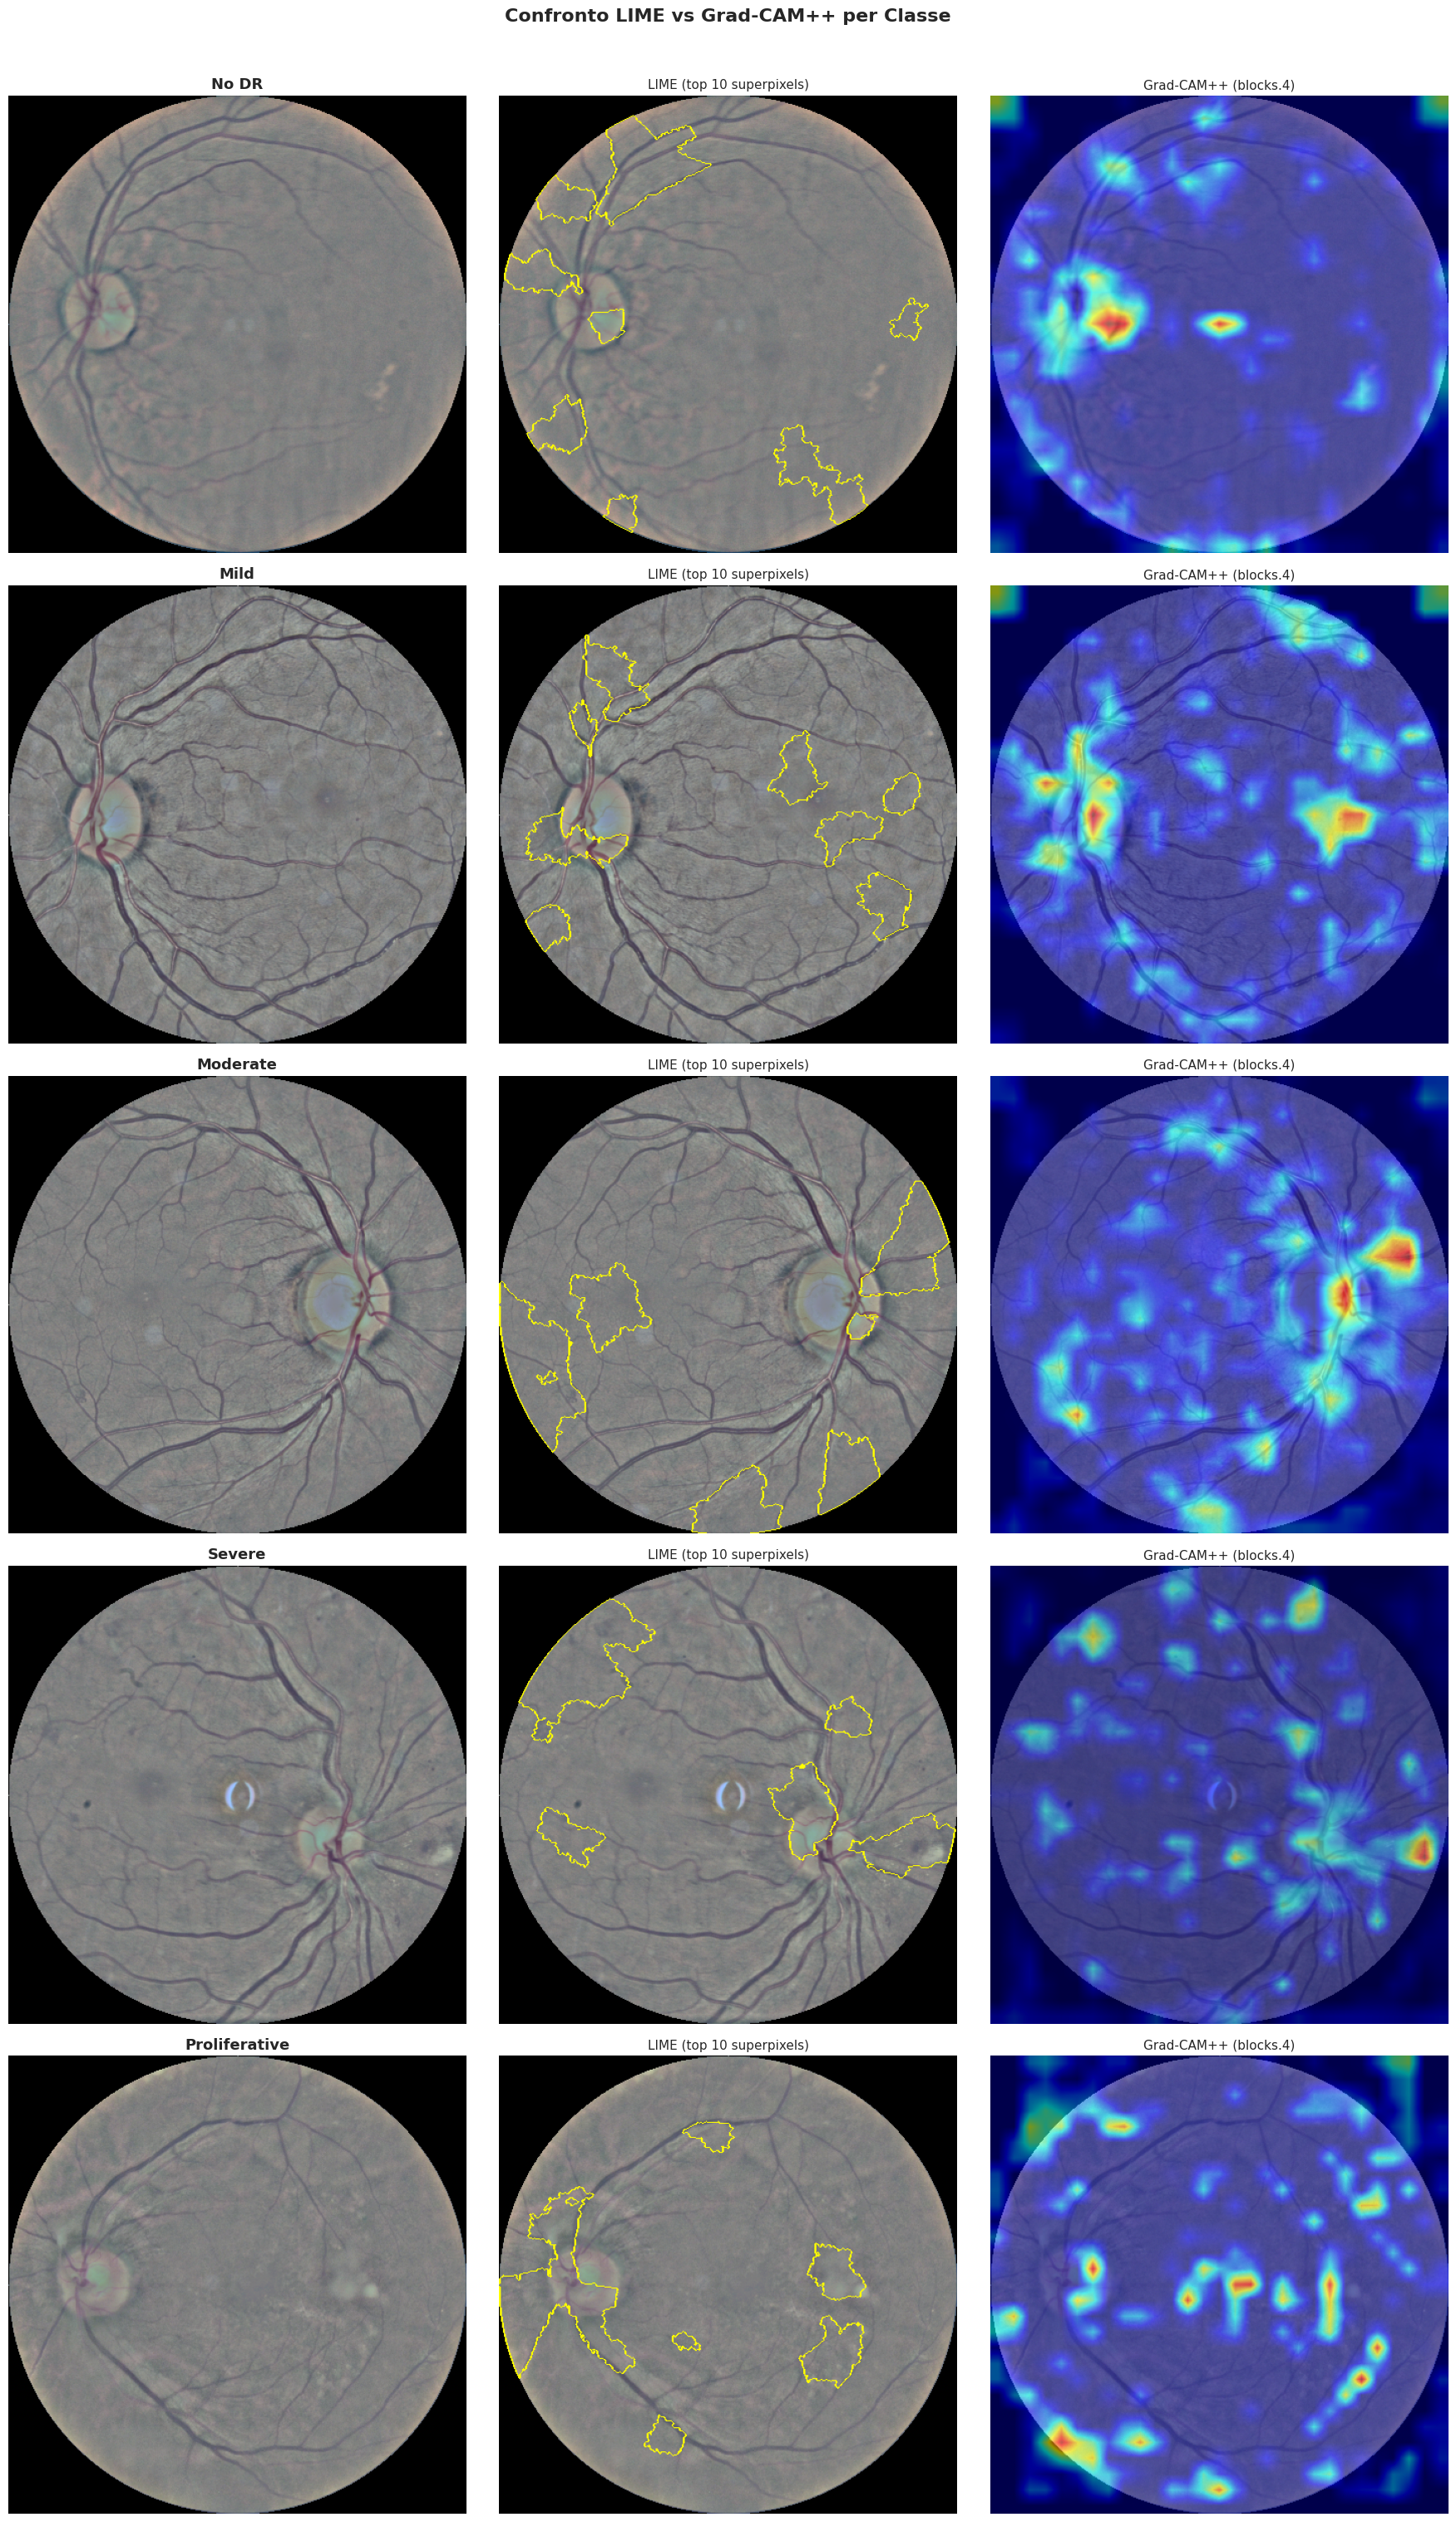

In [41]:
# Confronto visivo LIME vs Grad-CAM++ (1 campione per classe)
cam = GradCAMPlusPlus(model=model, target_layers=[model.blocks[4]])

fig, axes = plt.subplots(5, 3, figsize=(18, 30))

for cls in range(5):
    # Primo campione di questa classe
    cls_results = [r for r in lime_results if r['diagnosis'] == cls]
    if not cls_results:
        continue
    r = cls_results[0]
    image = r['image']
    explanation = r['explanation']
    image_float = image.astype(np.float32) / 255.0
    
    # Originale
    axes[cls, 0].imshow(image_float)
    axes[cls, 0].set_title(f'{CLASS_NAMES[cls]}', fontsize=13, fontweight='bold')
    axes[cls, 0].axis('off')
    
    # LIME
    temp, mask = explanation.get_image_and_mask(
        cls, positive_only=True, num_features=10, hide_rest=False
    )
    lime_overlay = mark_boundaries(image_float, mask)
    axes[cls, 1].imshow(lime_overlay)
    axes[cls, 1].set_title('LIME (top 10 superpixels)', fontsize=11)
    axes[cls, 1].axis('off')
    
    # Grad-CAM++
    tensor = val_transforms(image=image)['image'].unsqueeze(0).to(DEVICE)
    targets = [ClassifierOutputTarget(cls)]
    heatmap = cam(input_tensor=tensor, targets=targets)[0]
    gradcam_overlay = show_cam_on_image(image_float, heatmap, use_rgb=True)
    axes[cls, 2].imshow(gradcam_overlay)
    axes[cls, 2].set_title('Grad-CAM++ (blocks.4)', fontsize=11)
    axes[cls, 2].axis('off')

plt.suptitle('Confronto LIME vs Grad-CAM++ per Classe', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(RULE_DIR / 'lime_vs_gradcam.png', dpi=150, bbox_inches='tight')
plt.show()

del cam
torch.cuda.empty_cache()

Test stabilita LIME: classe No DR, 5 run


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  IoU medio tra run: 0.263 +/- 0.125
  IoU range: [0.107, 0.571]


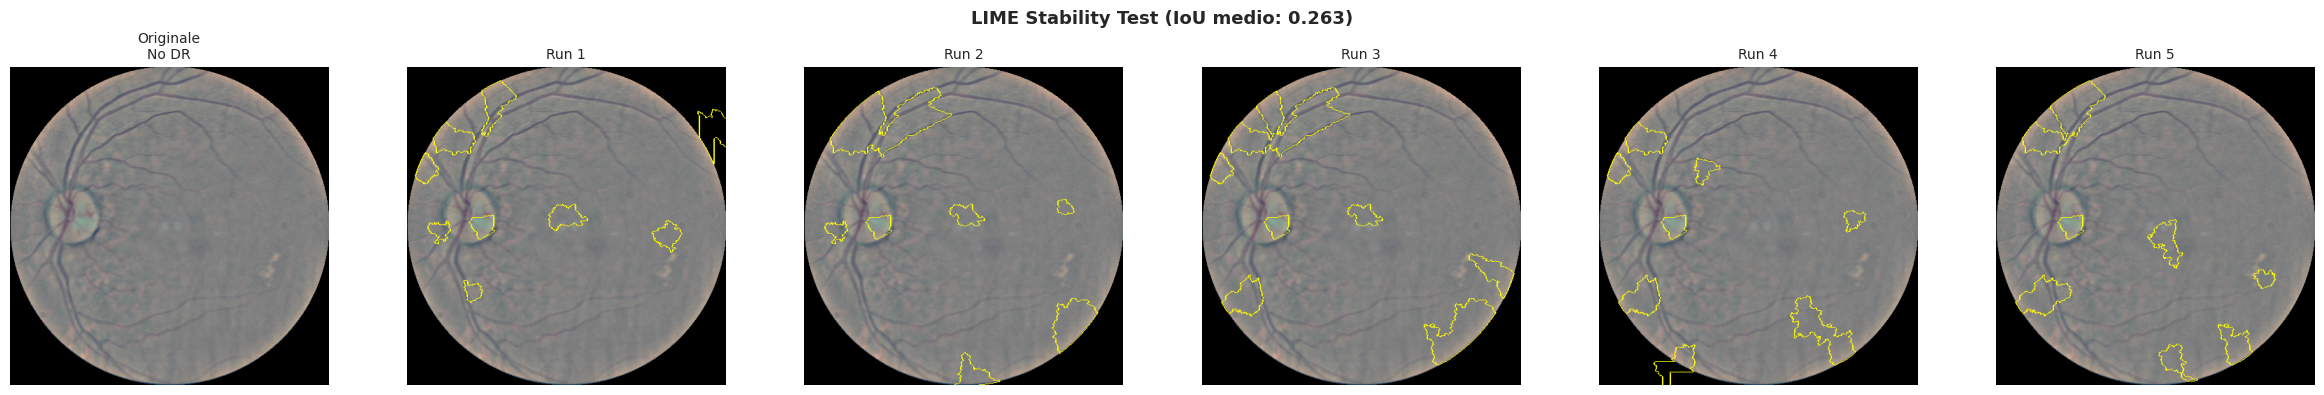

In [42]:
# LIME stabilita: stessa immagine, 5 run, misura consistenza
STABILITY_RUNS = 5
stability_sample = lime_results[0]  # Primo campione
image = stability_sample['image']
cls = stability_sample['diagnosis']

print(f"Test stabilita LIME: classe {CLASS_NAMES[cls]}, {STABILITY_RUNS} run")

stability_masks = []
for run in range(STABILITY_RUNS):
    exp = explainer.explain_instance(
        image,
        lime_predict_fn,
        top_labels=5,
        hide_color=0,
        num_samples=N_LIME_SAMPLES,
        random_seed=run  # seed diversi per ogni run
    )
    _, mask = exp.get_image_and_mask(cls, positive_only=True, num_features=10, hide_rest=False)
    stability_masks.append(mask)

# Calcola IoU tra coppie di mask
ious = []
for i in range(len(stability_masks)):
    for j in range(i+1, len(stability_masks)):
        intersection = np.logical_and(stability_masks[i], stability_masks[j]).sum()
        union = np.logical_or(stability_masks[i], stability_masks[j]).sum()
        if union > 0:
            ious.append(intersection / union)

print(f"  IoU medio tra run: {np.mean(ious):.3f} +/- {np.std(ious):.3f}")
print(f"  IoU range: [{np.min(ious):.3f}, {np.max(ious):.3f}]")

# Visualizza le 5 mask sovrapposte
fig, axes = plt.subplots(1, STABILITY_RUNS + 1, figsize=(4 * (STABILITY_RUNS + 1), 4))

image_float = image.astype(np.float32) / 255.0
axes[0].imshow(image_float)
axes[0].set_title(f'Originale\n{CLASS_NAMES[cls]}', fontsize=10)
axes[0].axis('off')

for run in range(STABILITY_RUNS):
    overlay = mark_boundaries(image_float, stability_masks[run])
    axes[run+1].imshow(overlay)
    axes[run+1].set_title(f'Run {run+1}', fontsize=10)
    axes[run+1].axis('off')

plt.suptitle(f'LIME Stability Test (IoU medio: {np.mean(ious):.3f})', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RULE_DIR / 'lime_stability.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Comparison Framework

Confronto quantitativo tra i 3 metodi di rule extraction.

In [43]:
# Tabella riepilogativa
comparison = {
    'Decision Tree (d=12)': {
        'val': dt_val_results,
        'test': dt_test_results,
        'complexity': {
            'type': 'tree',
            'nodes': int(dt_final.tree_.node_count),
            'leaves': int(dt_final.tree_.n_leaves),
            'max_depth': int(dt_final.tree_.max_depth)
        }
    },
    'RIPPER': {
        'val': ripper_val_results,
        'test': ripper_test_results,
        'complexity': {
            'type': 'ruleset',
            'n_rules': total_rules,
            'n_conditions': total_conditions,
            'avg_conditions': total_conditions / max(1, total_rules)
        }
    }
}

# Tabella
print("\n" + "=" * 80)
print("CONFRONTO METODI DI RULE EXTRACTION")
print("=" * 80)

print(f"\n{'Metodo':<25} {'Fidelity Val':>13} {'Fidelity Test':>14} {'Acc Val':>9} {'Acc Test':>9} {'F1 Val':>8} {'F1 Test':>8}")
print("-" * 90)

for method, data in comparison.items():
    fv = data['val']['fidelity']
    ft = data['test']['fidelity']
    av = data['val']['accuracy']
    at = data['test']['accuracy']
    f1v = data['val']['f1_macro']
    f1t = data['test']['f1_macro']
    print(f"{method:<25} {fv*100:>12.1f}% {ft*100:>13.1f}% {av*100:>8.1f}% {at*100:>8.1f}% {f1v:>8.4f} {f1t:>8.4f}")

# Fidelity per classe
print(f"\n{'Fidelity per classe (Val)':}")
print(f"{'Metodo':<25}", end='')
for cn in CLASS_NAMES:
    print(f" {cn:>12}", end='')
print()
print("-" * (25 + 13 * len(CLASS_NAMES)))

for method, data in comparison.items():
    print(f"{method:<25}", end='')
    for cn in CLASS_NAMES:
        fid = data['val']['fidelity_per_class'].get(cn, 0)
        print(f" {fid*100:>11.1f}%", end='')
    print()

# Complessita
print(f"\nComplessita:")
for method, data in comparison.items():
    c = data['complexity']
    if c['type'] == 'tree':
        print(f"  {method}: {c['nodes']} nodi, {c['leaves']} foglie, profondita {c['max_depth']}")
    else:
        print(f"  {method}: {c['n_rules']} regole, {c['n_conditions']} condizioni ({c['avg_conditions']:.1f} cond/regola)")


CONFRONTO METODI DI RULE EXTRACTION

Metodo                     Fidelity Val  Fidelity Test   Acc Val  Acc Test   F1 Val  F1 Test
------------------------------------------------------------------------------------------
Decision Tree (d=12)              92.6%          88.2%     84.3%     65.8%   0.7181   0.6218
RIPPER                            79.8%          63.0%     81.6%     68.2%   0.6142   0.5575

Fidelity per classe (Val)
Metodo                           No DR         Mild     Moderate       Severe Proliferative
------------------------------------------------------------------------------------------
Decision Tree (d=12)             97.0%        77.5%        88.6%        75.0%        91.5%
RIPPER                           98.5%        32.2%        45.5%        52.9%        63.1%

Complessita:
  Decision Tree (d=12): 1909 nodi, 955 foglie, profondita 12
  RIPPER: 48 regole, 48 condizioni (1.0 cond/regola)


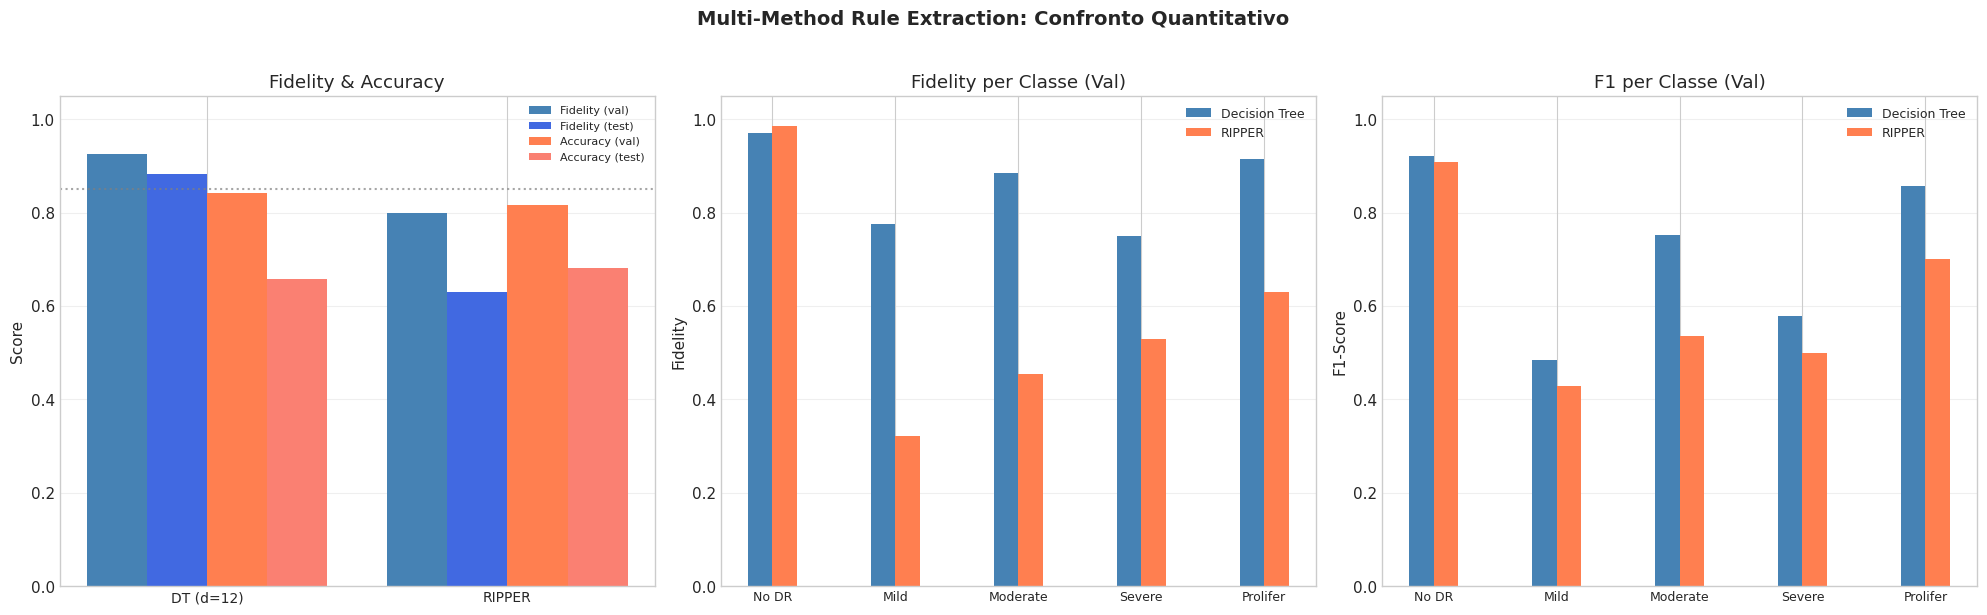

In [44]:
# Grafici di confronto
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

methods = list(comparison.keys())
colors = ['steelblue', 'coral']

# 1. Fidelity/Accuracy per metodo
x = np.arange(len(methods))
width = 0.2
axes[0].bar(x - width*1.5, [comparison[m]['val']['fidelity'] for m in methods], width, label='Fidelity (val)', color='steelblue')
axes[0].bar(x - width*0.5, [comparison[m]['test']['fidelity'] for m in methods], width, label='Fidelity (test)', color='royalblue')
axes[0].bar(x + width*0.5, [comparison[m]['val']['accuracy'] for m in methods], width, label='Accuracy (val)', color='coral')
axes[0].bar(x + width*1.5, [comparison[m]['test']['accuracy'] for m in methods], width, label='Accuracy (test)', color='salmon')
axes[0].axhline(y=0.85, color='gray', linestyle=':', alpha=0.7)
axes[0].set_xticks(x)
axes[0].set_xticklabels(['DT (d=12)', 'RIPPER'], fontsize=10)
axes[0].set_ylabel('Score')
axes[0].set_title('Fidelity & Accuracy')
axes[0].legend(fontsize=8)
axes[0].set_ylim(0, 1.05)
axes[0].grid(True, alpha=0.3, axis='y')

# 2. Fidelity per classe (val)
x_cls = np.arange(len(CLASS_NAMES))
for i, method in enumerate(methods):
    fids = [comparison[method]['val']['fidelity_per_class'][cn] for cn in CLASS_NAMES]
    axes[1].bar(x_cls + i * width - width/2, fids, width, label=method.split('(')[0].strip(), color=colors[i])

axes[1].set_xticks(x_cls)
axes[1].set_xticklabels([cn[:8] for cn in CLASS_NAMES], fontsize=9)
axes[1].set_ylabel('Fidelity')
axes[1].set_title('Fidelity per Classe (Val)')
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, 1.05)
axes[1].grid(True, alpha=0.3, axis='y')

# 3. F1 per classe (val)
for i, method in enumerate(methods):
    f1s = [comparison[method]['val']['f1_per_class'][cn] for cn in CLASS_NAMES]
    axes[2].bar(x_cls + i * width - width/2, f1s, width, label=method.split('(')[0].strip(), color=colors[i])

axes[2].set_xticks(x_cls)
axes[2].set_xticklabels([cn[:8] for cn in CLASS_NAMES], fontsize=9)
axes[2].set_ylabel('F1-Score')
axes[2].set_title('F1 per Classe (Val)')
axes[2].legend(fontsize=9)
axes[2].set_ylim(0, 1.05)
axes[2].grid(True, alpha=0.3, axis='y')

plt.suptitle('Multi-Method Rule Extraction: Confronto Quantitativo', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(RULE_DIR / 'method_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Salvataggio Risultati

In [46]:
# Salva metriche complete
class NumpyEncoder(json.JSONEncoder):
    """Encoder JSON che converte tipi numpy in tipi Python nativi."""
    def default(self, obj):
        if isinstance(obj, (np.integer,)):
            return int(obj)
        if isinstance(obj, (np.floating,)):
            return float(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        return super().default(obj)

all_metrics = {
    'model': str(CHECKPOINT_PATH.name),
    'pca_components': int(n_components),
    'pca_variance_explained': float(explained_var),
    'methods': {}
}

for method, data in comparison.items():
    all_metrics['methods'][method] = {
        'validation': {
            'fidelity': float(data['val']['fidelity']),
            'accuracy': float(data['val']['accuracy']),
            'f1_macro': float(data['val']['f1_macro']),
            'f1_per_class': data['val']['f1_per_class'],
            'fidelity_per_class': data['val']['fidelity_per_class']
        },
        'test': {
            'fidelity': float(data['test']['fidelity']),
            'accuracy': float(data['test']['accuracy']),
            'f1_macro': float(data['test']['f1_macro']),
            'f1_per_class': data['test']['f1_per_class'],
            'fidelity_per_class': data['test']['fidelity_per_class']
        },
        'complexity': data['complexity']
    }

# LIME stability
all_metrics['lime'] = {
    'n_samples_per_explanation': int(N_LIME_SAMPLES),
    'n_images_explained': len(lime_results),
    'stability_iou_mean': float(np.mean(ious)),
    'stability_iou_std': float(np.std(ious)),
    'stability_runs': int(STABILITY_RUNS)
}

# Ablation DT
all_metrics['dt_ablation'] = ablation_results

metrics_path = RULE_DIR / 'rule_extraction_metrics.json'
with open(metrics_path, 'w') as f:
    json.dump(all_metrics, f, indent=2, cls=NumpyEncoder)

print(f"Metriche salvate: {metrics_path}")
print(f"\nArtefatti generati:")
for f in sorted(RULE_DIR.glob('*.png')):
    print(f"  {f.name}")
for f in sorted(RULE_DIR.glob('*.json')):
    print(f"  {f.name}")
for f in sorted(RULE_DIR.glob('*.npz')):
    print(f"  {f.name}")

Metriche salvate: /mnt/c/Repository/multi-method-xai-diabetic-retinopathy/results/rule_extraction/rule_extraction_metrics.json

Artefatti generati:
  dt_ablation_depth.png
  dt_feature_importance.png
  lime_stability.png
  lime_vs_gradcam.png
  method_comparison.png
  pca_variance.png
  rule_extraction_metrics.json
  features_test.npz
  features_train.npz
  features_val.npz


In [47]:
# Riepilogo finale
print("\n" + "=" * 70)
print("RIEPILOGO - RULE EXTRACTION")
print("=" * 70)

print(f"\nModello teacher: {CHECKPOINT_PATH.name}")
print(f"Feature: 2048 -> {n_components} (PCA, {explained_var*100:.1f}% var)")

print(f"\n--- Confronto Metodi (Validation) ---")
print(f"  {'Metodo':<25} {'Fidelity':>10} {'Accuracy':>10} {'F1 Macro':>10}")
print(f"  {'-'*55}")
for method, data in comparison.items():
    print(f"  {method:<25} {data['val']['fidelity']*100:>9.1f}% {data['val']['accuracy']*100:>9.1f}% {data['val']['f1_macro']:>10.4f}")

print(f"\n--- LIME ---")
print(f"  Campioni spiegati: {len(lime_results)}")
print(f"  Stabilita (IoU): {np.mean(ious):.3f} +/- {np.std(ious):.3f}")

print(f"\n--- Prossimi Step ---")
print(f"  Notebook 07: Sistema Ibrido (CNN + regole)")
print(f"  - Post-hoc explanation: CNN predice, regole spiegano")
print(f"  - Rule-guided: regole filtrano, CNN decide casi ambigui")
print(f"  - Ensemble: weighted voting CNN + regole")


RIEPILOGO - RULE EXTRACTION

Modello teacher: best_model_20260118_224715.pt
Feature: 2048 -> 12 (PCA, 95.2% var)

--- Confronto Metodi (Validation) ---
  Metodo                      Fidelity   Accuracy   F1 Macro
  -------------------------------------------------------
  Decision Tree (d=12)           92.6%      84.3%     0.7181
  RIPPER                         79.8%      81.6%     0.6142

--- LIME ---
  Campioni spiegati: 25
  Stabilita (IoU): 0.263 +/- 0.125

--- Prossimi Step ---
  Notebook 07: Sistema Ibrido (CNN + regole)
  - Post-hoc explanation: CNN predice, regole spiegano
  - Rule-guided: regole filtrano, CNN decide casi ambigui
  - Ensemble: weighted voting CNN + regole


## 8. Conclusioni

### Risultati Chiave

1. **Decision Tree**: Metodo globale che produce regole interpretabili basate sulle feature PCA della CNN. Ablation study mostra il trade-off profondita/fidelity.

2. **RIPPER**: Regole if-then piu compatte del DT, ottimizzate per coverage e accuracy. Produce un insieme ordinato di regole indipendenti.

3. **LIME**: Spiegazioni locali per immagine. Complementare ai metodi globali (DT, RIPPER): non produce regole ma identifica le regioni visive rilevanti per ogni predizione.

### Confronto
- **DT e RIPPER** sono confrontabili su fidelity/accuracy (metriche globali)
- **LIME** opera a livello diverso (locale vs globale) e si confronta visivamente con Grad-CAM++
- Il test di stabilita LIME quantifica la riproducibilita delle spiegazioni

### Prossimi Step
- **Notebook 07**: Sistema Ibrido che combina CNN + regole per classificazione interpretabile